# Decision Tree - Multi-Class Classification

## Table of Contents

1. [**Introduction**](#Intro)  
    
2. [**Model Development Procedure**](#ModelDevp)

3. [**Model Development**](#Class)
   
4. [**Multi-Class Classification Evaluation Metrics**](#Metrics)

## 1 Introduction <a name="Intro"></a>

A decision tree is a flowchart-like tree structure where: 

- Each internal node (decision node) denotes a test on a feature
- Each branch represents an outcome of the test
- Each leaf node (or terminal node) holds a class label
- The topmost node is the root node

### Binary vs. Multi-Class Classification

**Binary Classification:**
- Only two possible classes (e.g., Faulty/No Fault, Yes/No, 0/1)
- Simple evaluation metrics (accuracy, precision, recall, F1)

**Multi-Class Classification:**
- Three or more possible classes (e.g., Fault Type A/B/C/D)
- More complex evaluation - need to consider performance across all classes
- Requires different approaches to metrics (micro, macro, weighted averaging)

In this notebook, we'll work with **multi-class classification** where we classify steel plates into different fault categories.


## 2 Model Development Procedure <a name="ModelDevp"></a>

Here are the steps to implement decision tree classification in Python using <font color='blue'>scikit-learn</font> library

__1.__ Import `DecisionTreeClassifier`, `train_test_split`, and `MinMaxScaler` functions from scikit-learn library along with `numpy` library
```python
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler  # For normalization
import numpy as np
```

__2.__ Define dependent (target variable) and independent variables (features) from dataset:
```python
x_data=np.array(df[['feature1','feature2',...]])
y_data=df['target variable']
```

__3.__ Normalize your data using <font color='blue'>MinMaxScaler</font> (Optional - not neccessary for Decision Tree)
```python
MinMaxscaler = MinMaxScaler()  # define min max scaler
x_data_scaled = MinMaxscaler.fit_transform(x_data)  # transform data
```

__4.__ Split the data into train and test sets: `x_train,x_test,y_train,y_test=train_test_split(x_data_scaled,y_data, stratify=y_data)`

**Note:** For multi-class problems, use `stratify=y_data` to maintain class distribution in train/test splits.

__5.__ Create a decision tree object using the constructor: `dt = DecisionTreeClassifier() `

__6.__ Use the fit function to fit the model to the training data: `dt.fit(x_train,y_train)`

__7.__ Then, make predictions using the test data and training data:
```python
yhatTest=dt.predict(x_test)
yhatTrain=dt.predict(x_train)
```

__8.__ Create visualizations (Optional)

__9.__ Model Evaluation using multi-class metrics

## 3 Model Development<a name="Class"></a>

### Dataset Description

Steel plate faults dataset is provided by Semeion, Research of Sciences of Communication, Via Sersale 117, 00128, Rome, Italy. In this dataset, the faults of steel plates are classified into 7 types. Since it has been donated on October 26, 2010, this dataset has been widely used in machine learning for automatic pattern recognition. Types of fault and corresponding numbers of samples are shown in the table below:

<img src="https://docs.google.com/uc?export=download&id=1pw1oJ7plDsTASg_ntI_QSVivQ-tMhlqq" width="500">

The number of samples varies a lot from one category to another. For every sample, 27 features are recorded, providing evidence for its fault class. All attributes are expressed by integers or real numbers. Detailed information about these 27 independent variables is listed out in the following table.

<img src="https://docs.google.com/uc?export=download&id=1lAV-mPa2seL9VWkezbaCicnZVwOup2c6" width="500">

### Creating Multi-Class Target

In this notebook, we'll create a **multi-class classification problem** by combining different fault types into a single target variable with 3 classes:
- **Class 1**: Pastry fault only
- **Class 2**: Scratch faults (Z_Scratch or K_Scratch)
- **Class 3**: Other faults (Stains, Dirtiness, Bumps, or Other_Faults)

Ref: https://www.sciencedirect.com/science/article/pii/S0925231214012193

Ref for the dataset: https://archive.ics.uci.edu/ml/datasets/Steel+Plates+Faults


### Loading and Exploring the Data

In [1]:
import pandas as pd
import numpy as np

url = ('https://raw.githubusercontent.com/MasoudMiM/ME_364/main/Steel_Plates_Faults/Data.csv')
df = pd.read_csv(url, names=['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter',
                              'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity',
                              'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
                              'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index',
                              'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index',
                              'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas', 'Pastry', 'Z_Scratch',
                              'K_Scratch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults'])           
df.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scratch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


In [2]:
# Check to see if there are missing values in the dataset
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Dataset shape: {df.shape}")

Total missing values: 0
Dataset shape: (1941, 34)


### Creating Multi-Class Target Variable

We'll create a new column `Fault_Type` that combines the different fault categories into 4 classes:

In [ ]:
def create_fault_type(row):
    """
    Create multi-class target based on fault types:
    - Class 1: Pastry fault
    - Class 2: Scratch faults (Z_Scratch or K_Scratch)
    - Class 3: Other faults (Stains, Dirtiness, Bumps, Other_Faults)
    """
    if row['Pastry'] == 1:
        return 1
    elif row['Z_Scratch'] == 1 or row['K_Scratch'] == 1:
        return 2
    elif row['Stains'] == 1 or row['Dirtiness'] == 1 or row['Bumps'] == 1 or row['Other_Faults'] == 1:
        return 3

# Apply the function to create new target variable
df['Fault_Type'] = df.apply(create_fault_type, axis=1)

# Display the distribution
print("\nFault Type Distribution:")
print(df['Fault_Type'].value_counts().sort_index())
print("\nPercentage Distribution:")
print((df['Fault_Type'].value_counts(normalize=True).sort_index() * 100).round(2))


Fault Type Distribution:
Fault_Type
1     158
2     581
3    1202
Name: count, dtype: int64

Percentage Distribution:
Fault_Type
1     8.14
2    29.93
3    61.93
Name: proportion, dtype: float64


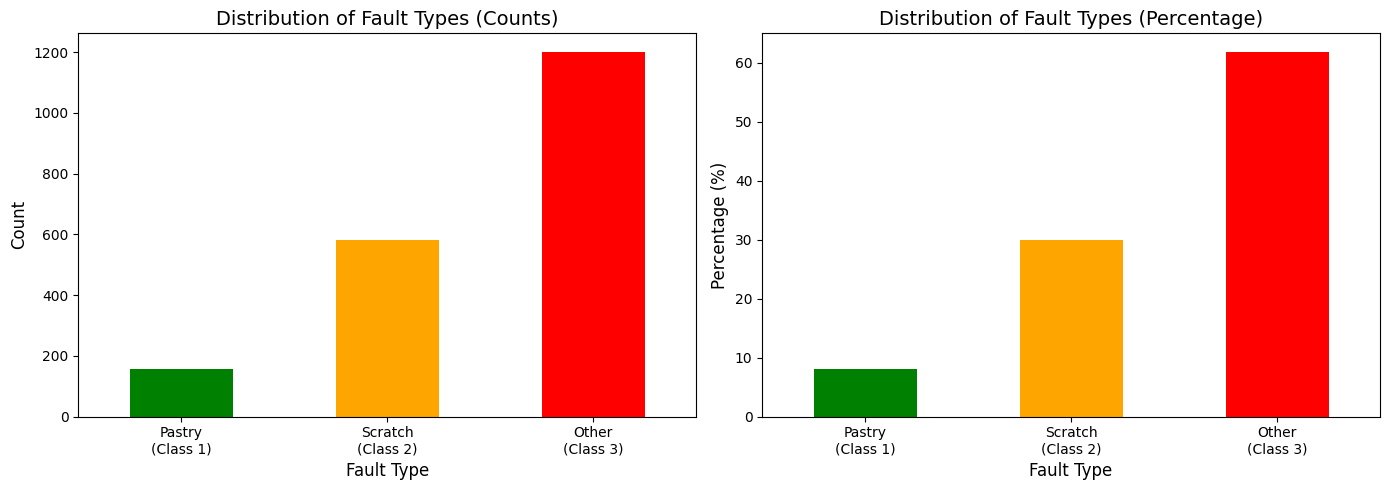

In [5]:
# Visualize the class distribution
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df['Fault_Type'].value_counts().sort_index().plot(kind='bar', ax=ax1, color=['green', 'orange', 'red', 'purple'])
ax1.set_xlabel('Fault Type', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Distribution of Fault Types (Counts)', fontsize=14)
ax1.set_xticklabels(['Pastry\n(Class 1)', 'Scratch\n(Class 2)', 'Other\n(Class 3)'], rotation=0)

# Percentage plot
(df['Fault_Type'].value_counts(normalize=True).sort_index() * 100).plot(
    kind='bar', ax=ax2, color=['green', 'orange', 'red', 'purple'])
ax2.set_xlabel('Fault Type', fontsize=12)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_title('Distribution of Fault Types (Percentage)', fontsize=14)
ax2.set_xticklabels(['Pastry\n(Class 1)', 'Scratch\n(Class 2)', 'Other\n(Class 3)'], rotation=0)

plt.tight_layout()
plt.show()

**Observation:** Notice that the classes are **imbalanced**. This is common in real-world problems and affects how we evaluate our model!

### Step 1: Importing the Required Libraries

In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler  # For normalization
import numpy as np

### Step 2: Defining Dependent and Independent Variables

In [7]:
# Select features (same features as before)
features = ['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter',
            'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity',
            'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness']

# Define X (features) and y (target)
x_data = np.array(df[features])
y_data = df['Fault_Type']  # Multi-class target

print(f"Feature matrix shape: {x_data.shape}")
print(f"Target variable shape: {y_data.shape}")
print(f"\nUnique classes in target: {sorted(y_data.unique())}")

Feature matrix shape: (1941, 13)
Target variable shape: (1941,)

Unique classes in target: [np.int64(1), np.int64(2), np.int64(3)]


### Step 3: Normalization using MinMaxScaler

In [8]:
MinMaxscaler = MinMaxScaler()  # define min max scaler
x_data_scaled = MinMaxscaler.fit_transform(x_data)  # transform data

print("Data normalized successfully!")
print(f"Feature range after scaling: [{x_data_scaled.min():.3f}, {x_data_scaled.max():.3f}]")

Data normalized successfully!
Feature range after scaling: [0.000, 1.000]


### Step 4: Splitting into Train and Test Sets

**Important:** We use `stratify=y_data` to ensure that the class distribution is maintained in both train and test sets. This is crucial for multi-class problems, especially with imbalanced classes.

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    x_data_scaled, 
    y_data, 
    test_size=0.25, 
    random_state=101,
    stratify=y_data  # Maintain class distribution
)

print(f"Training set size: {x_train.shape[0]} samples")
print(f"Test set size: {x_test.shape[0]} samples")
print("\nClass distribution in training set:")
print(y_train.value_counts().sort_index())
print("\nClass distribution in test set:")
print(y_test.value_counts().sort_index())

Training set size: 1455 samples
Test set size: 486 samples

Class distribution in training set:
Fault_Type
1    118
2    436
3    901
Name: count, dtype: int64

Class distribution in test set:
Fault_Type
1     40
2    145
3    301
Name: count, dtype: int64


### Step 5: Creating Decision Tree Model

In [10]:
# Create decision tree with some hyperparameters to prevent overfitting
dt = DecisionTreeClassifier(
    max_depth=10,           # Limit tree depth
    min_samples_split=20,   # Minimum samples to split a node
    min_samples_leaf=10,    # Minimum samples in a leaf
    random_state=101
)

print("Decision Tree Classifier created with parameters:")
print(f"  - Max depth: {dt.max_depth}")
print(f"  - Min samples split: {dt.min_samples_split}")
print(f"  - Min samples leaf: {dt.min_samples_leaf}")

Decision Tree Classifier created with parameters:
  - Max depth: 10
  - Min samples split: 20
  - Min samples leaf: 10


### Step 6: Training the Model

In [11]:
dt.fit(x_train, y_train)
print("Model trained successfully!")
print(f"Number of classes: {dt.n_classes_}")
print(f"Classes: {dt.classes_}")

Model trained successfully!
Number of classes: 3
Classes: [1 2 3]


### Step 7: Making Predictions

In [12]:
yhatTest = dt.predict(x_test)
yhatTrain = dt.predict(x_train)

print("Predictions made successfully!")
print(f"\nFirst 10 test predictions: {yhatTest[:10]}")
print(f"First 10 actual test values: {y_test.values[:10]}")

Predictions made successfully!

First 10 test predictions: [2 3 3 3 3 3 2 3 1 3]
First 10 actual test values: [2 3 3 3 3 3 2 3 1 1]


### Step 8: Visualizing the Decision Tree

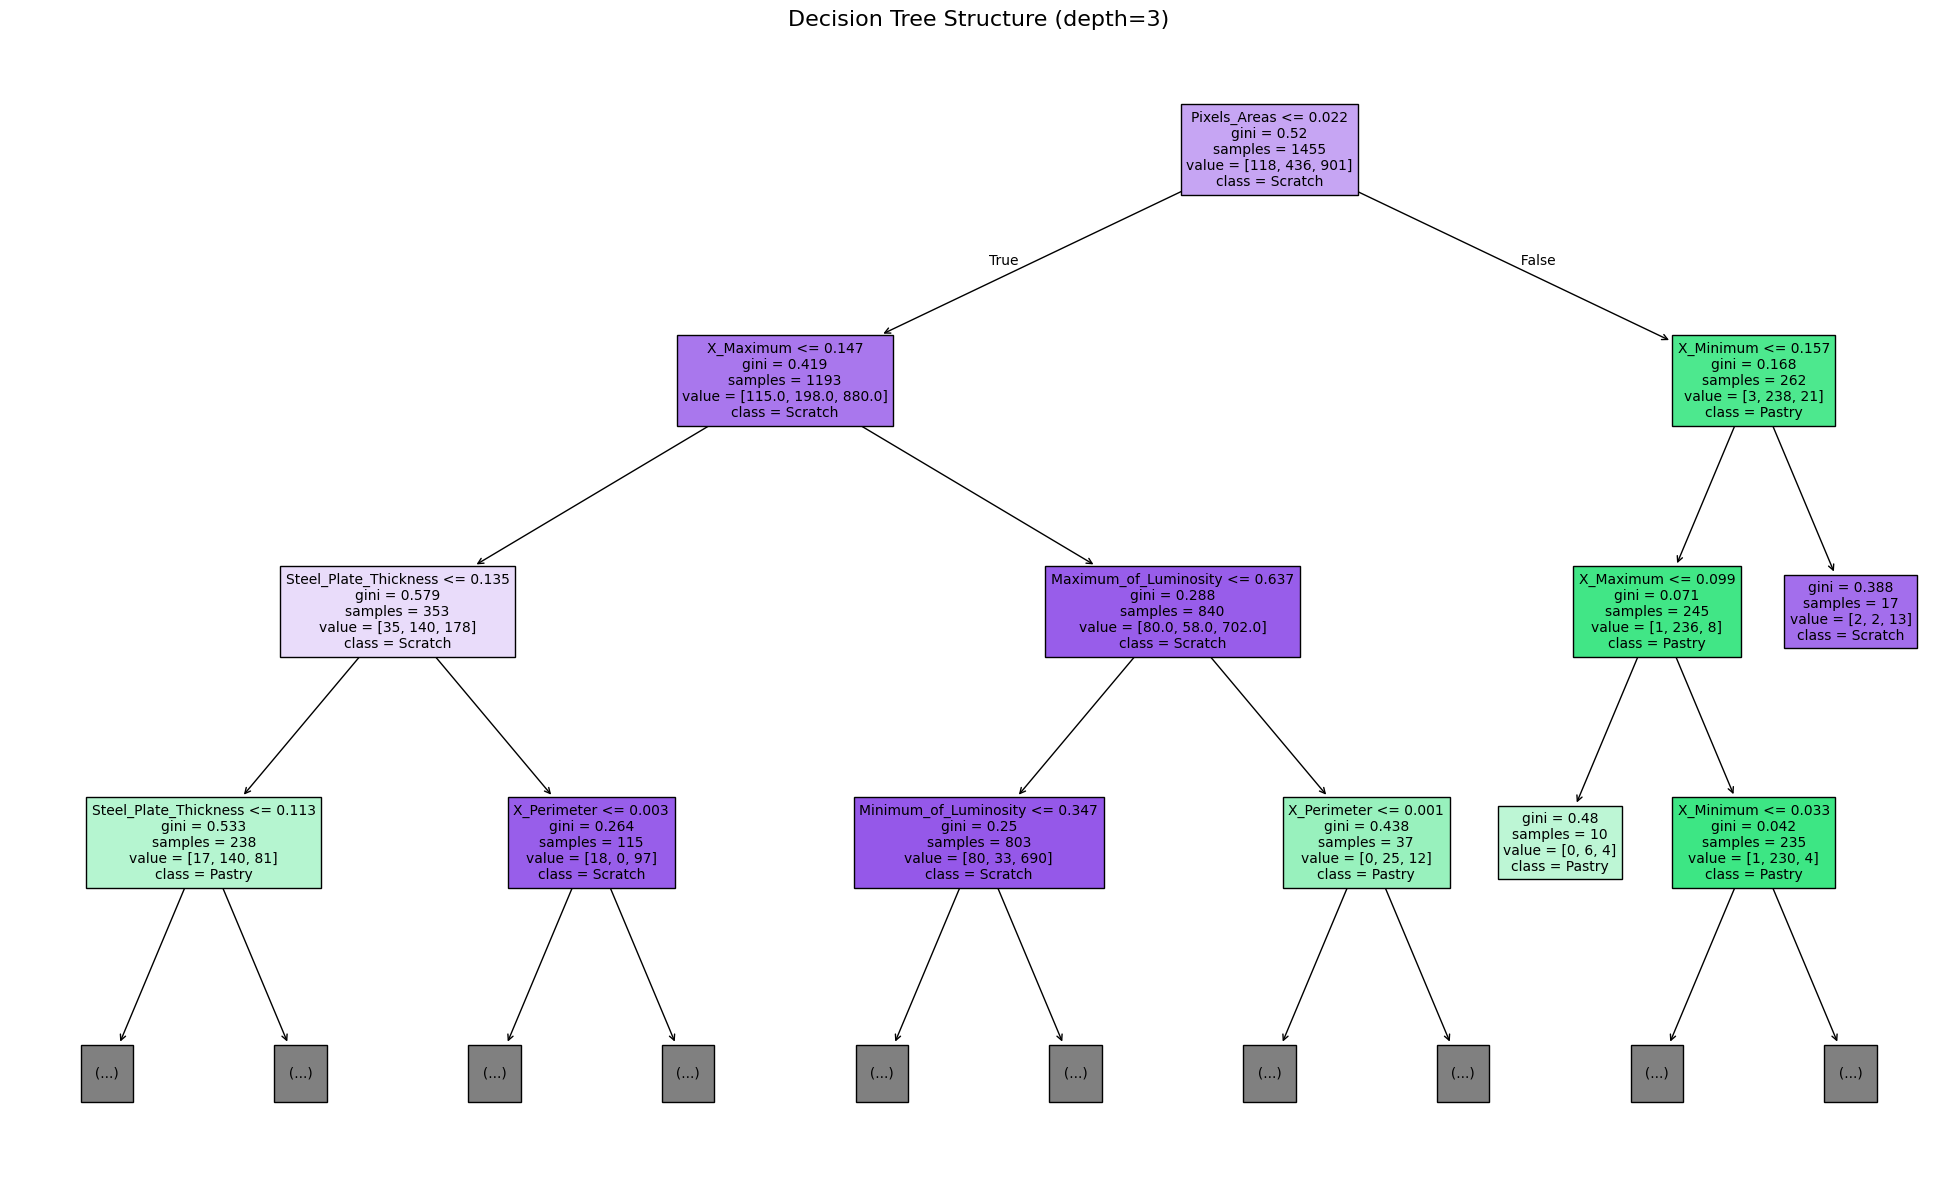

In [13]:
# Visualize tree structure (limited depth for readability)
plt.figure(figsize=(25, 15))
tree.plot_tree(
    dt, 
    max_depth=3,  # Show only first 3 levels
    feature_names=features,
    class_names=['No Fault', 'Pastry', 'Scratch', 'Other'],
    filled=True,
    fontsize=10
)
plt.title('Decision Tree Structure (depth=3)', fontsize=16)
plt.show()

In [14]:
# Text representation
text_representation = tree.export_text(dt, max_depth=3, feature_names=features)
print("Decision Tree Rules (first 3 levels):")
print(text_representation)

Decision Tree Rules (first 3 levels):
|--- Pixels_Areas <= 0.02
|   |--- X_Maximum <= 0.15
|   |   |--- Steel_Plate_Thickness <= 0.13
|   |   |   |--- Steel_Plate_Thickness <= 0.11
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Steel_Plate_Thickness >  0.11
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- Steel_Plate_Thickness >  0.13
|   |   |   |--- X_Perimeter <= 0.00
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- X_Perimeter >  0.00
|   |   |   |   |--- truncated branch of depth 2
|   |--- X_Maximum >  0.15
|   |   |--- Maximum_of_Luminosity <= 0.64
|   |   |   |--- Minimum_of_Luminosity <= 0.35
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Minimum_of_Luminosity >  0.35
|   |   |   |   |--- truncated branch of depth 7
|   |   |--- Maximum_of_Luminosity >  0.64
|   |   |   |--- X_Perimeter <= 0.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- X_Perimeter >  0.00
|   |   |   |   |--- class: 3
|

### Feature Importance

Feature Importances:
                  feature  importance
4            Pixels_Areas    0.407108
12  Steel_Plate_Thickness    0.139679
1               X_Maximum    0.122426
8   Minimum_of_Luminosity    0.075788
9   Maximum_of_Luminosity    0.068622
0               X_Minimum    0.067500
5             X_Perimeter    0.038115
11       TypeOfSteel_A400    0.021618
3               Y_Maximum    0.014845
6             Y_Perimeter    0.013788
2               Y_Minimum    0.013350
10       TypeOfSteel_A300    0.010974
7       Sum_of_Luminosity    0.006187


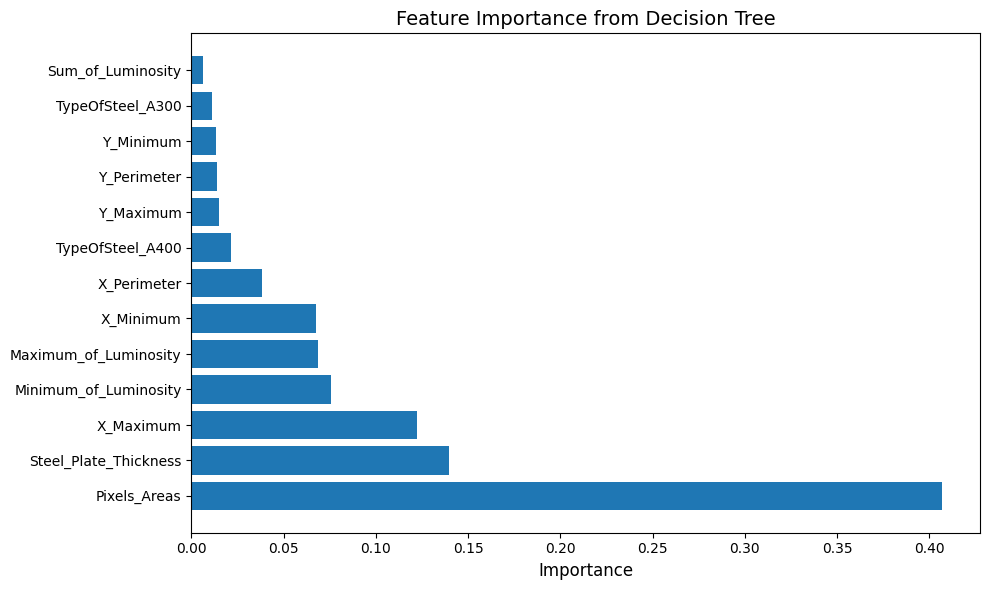

In [15]:
# Get feature importances
importances = dt.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Feature Importances:")
print(feature_importance_df)

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance from Decision Tree', fontsize=14)
plt.tight_layout()
plt.show()

## 4 Multi-Class Classification Evaluation Metrics <a name="Metrics"></a>

When dealing with multi-class classification, evaluation becomes more complex than binary classification. Let's understand the key metrics:

### 4.1 Confusion Matrix for Multi-Class

For a problem with **K classes**, the confusion matrix is a **K × K matrix** where:
- Rows represent **actual (true) classes**
- Columns represent **predicted classes**
- Cell (i,j) shows the number of samples that are actually class i but predicted as class j
- **Diagonal elements** represent correct predictions

Example for 3 classes:


| | Predicted: Class 0 | Predicted: Class 1 | Predicted: Class 2 |
|---|---|---|---|
| **Actual: Class 0** | 100 | 5 | 3 |
| **Actual: Class 1** | 4 | 85 | 6 |
| **Actual: Class 2** | 2 | 8 | 90 |


Interpretation:
- **Class 0**: 100 correct predictions, 8 errors (5 + 3)
- **Class 1**: 85 correct predictions, 10 errors (4 + 6)
- **Class 2**: 90 correct predictions, 10 errors (2 + 8)

### 4.2 Precision, Recall, and F1-Score

For **each class i**, we can compute:

**Precision (Class i):** Of all samples predicted as class i, what fraction were actually class i?
- Formula: $Precision_i = TP_i / (TP_i + FP_i)$
- $TP_i$ = True Positives for class i (diagonal element)
- $FP_i$ = False Positives for class i (sum of column i, excluding diagonal)

**Recall (Class i):** Of all samples that are actually class i, what fraction did we predict correctly?
- Formula: $Recall_i = TP_i / (TP_i + FN_i)$
- $FN_i$ = False Negatives for class i (sum of row i, excluding diagonal)

**F1-Score (Class i):** Harmonic mean of precision and recall
- Formula: $F1_i = 2 * (Precision_i * Recall_i) / (Precision_i + Recall_i)$

### 4.3 Averaging Methods

Since we get precision/recall/F1 for each class, how do we summarize overall performance? Three main approaches:

**1. Macro Average:**
- Calculate metric for each class independently
- Take the **unweighted mean** across all classes
- Formula: `Macro_Avg = (Metric_1 + Metric_2 + ... + Metric_K) / K`
- **Treats all classes equally**, regardless of size
- Good when you care about all classes equally (even rare ones)

**2. Micro Average:**
- Aggregate all TP, FP, FN across all classes
- Calculate metric from aggregated counts
- Formula: `Micro_Avg = Sum(TP_all) / (Sum(TP_all) + Sum(FP_all))`
- **Gives more weight to common classes**
- Good when classes are imbalanced and you care more about overall accuracy

**3. Weighted Average:**
- Calculate metric for each class
- Take **weighted mean** by number of samples in each class
- Formula: `Weighted_Avg = Σ(Metric_i * n_i) / Σ(n_i)` where n_i is number of samples in class i
- **Accounts for class imbalance**
- Most commonly used for imbalanced datasets

### 4.4 Which Average to Use?

- **Macro**: Use when all classes are equally important (e.g., disease diagnosis where rare diseases matter)
- **Micro**: Use when you care about overall sample-level accuracy
- **Weighted**: Use for imbalanced datasets where common classes are more important

### 4.5 Accuracy in Multi-Class

Accuracy remains simple:
- Formula: `Accuracy = (Number of correct predictions) / (Total predictions)`
- Same as: `Sum of diagonal elements / Total samples`
- **Warning:** Can be misleading with imbalanced classes!


Now we'll evaluate our multi-class classifier using various metrics. Pay close attention to how these differ from binary classification!

In [16]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

Accuracy is straightforward even for multi-class: fraction of correctly classified samples.

In [17]:
acc_scoreTrain = accuracy_score(y_train, yhatTrain)
acc_scoreTest = accuracy_score(y_test, yhatTest)

print("="*60)
print("ACCURACY SCORES")
print("="*60)
print(f'Training accuracy: {acc_scoreTrain:.4f} ({acc_scoreTrain*100:.2f}%)')
print(f'Test accuracy:     {acc_scoreTest:.4f} ({acc_scoreTest*100:.2f}%)')
print("="*60)

ACCURACY SCORES
Training accuracy: 0.8962 (89.62%)
Test accuracy:     0.8272 (82.72%)


The confusion matrix shows the complete picture of classification performance across all classes.

**Reading the matrix:**
- Each row represents samples from one actual class
- Each column represents predictions for one class
- Diagonal elements = correct predictions
- Off-diagonal elements = errors (misclassifications)

**Example interpretation:**
- If CM[1,2] = 15, it means 15 samples of actual Class 1 were incorrectly predicted as Class 2

In [ ]:
# Confusion matrix for training data
CM_scoreTrain = confusion_matrix(y_train, yhatTrain)
# Confusion matrix for test data
CM_scoreTest = confusion_matrix(y_test, yhatTest)

CONFUSION MATRIX - TRAINING DATA
[[ 61   2  55]
 [  2 396  38]
 [ 23  31 847]]

CONFUSION MATRIX - TEST DATA
[[ 10   5  25]
 [  2 125  18]
 [ 18  16 267]]


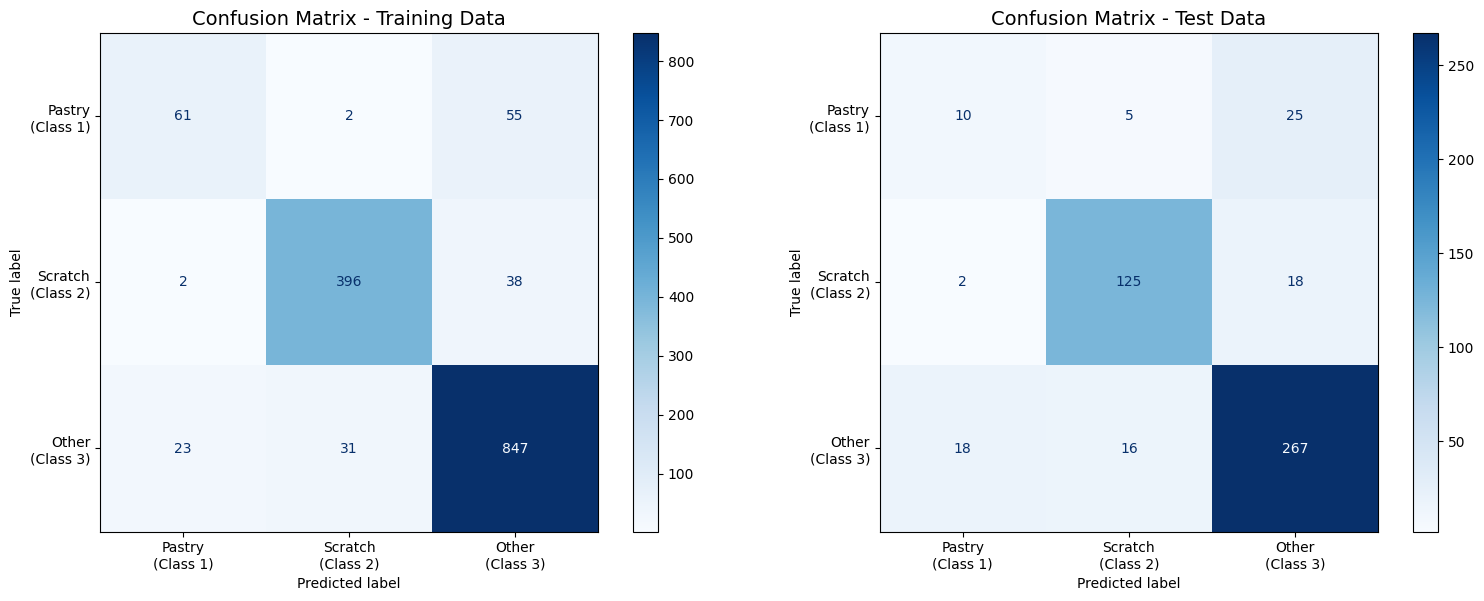

In [20]:
# Visualize confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

class_labels = ['Pastry\n(Class 1)', 
                'Scratch\n(Class 2)', 'Other\n(Class 3)']

# Training confusion matrix
disp_train = ConfusionMatrixDisplay(CM_scoreTrain, display_labels=class_labels)
disp_train.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title('Confusion Matrix - Training Data', fontsize=14)
ax1.grid(False)

# Test confusion matrix
disp_test = ConfusionMatrixDisplay(CM_scoreTest, display_labels=class_labels)
disp_test.plot(ax=ax2, cmap='Blues', values_format='d')
ax2.set_title('Confusion Matrix - Test Data', fontsize=14)
ax2.grid(False)

plt.tight_layout()
plt.show()

For multi-class classification, we need to specify how to average metrics across classes:
- **macro**: Unweighted mean (treats all classes equally)
- **weighted**: Weighted by number of samples (accounts for imbalance)
- **micro**: Aggregate all classes then compute (same as accuracy for classification)
- **None**: Returns scores for each class individually

In [22]:
print("="*80)
print("PRECISION SCORES")
print("="*80)

# Precision with different averaging methods
precision_macro_train = precision_score(y_train, yhatTrain, average='macro')
precision_macro_test = precision_score(y_test, yhatTest, average='macro')

precision_weighted_train = precision_score(y_train, yhatTrain, average='weighted')
precision_weighted_test = precision_score(y_test, yhatTest, average='weighted')

precision_micro_train = precision_score(y_train, yhatTrain, average='micro')
precision_micro_test = precision_score(y_test, yhatTest, average='micro')

print(f"{'Averaging Method':<20} {'Training':<15} {'Test':<15}")
print("-" * 80)
print(f"{'Macro Average':<20} {precision_macro_train:<15.4f} {precision_macro_test:<15.4f}")
print(f"{'Weighted Average':<20} {precision_weighted_train:<15.4f} {precision_weighted_test:<15.4f}")
print(f"{'Micro Average':<20} {precision_micro_train:<15.4f} {precision_micro_test:<15.4f}")
print("="*80)

print("\n" + "="*80)
print("RECALL SCORES")
print("="*80)

# Recall with different averaging methods
recall_macro_train = recall_score(y_train, yhatTrain, average='macro')
recall_macro_test = recall_score(y_test, yhatTest, average='macro')

recall_weighted_train = recall_score(y_train, yhatTrain, average='weighted')
recall_weighted_test = recall_score(y_test, yhatTest, average='weighted')

recall_micro_train = recall_score(y_train, yhatTrain, average='micro')
recall_micro_test = recall_score(y_test, yhatTest, average='micro')

print(f"{'Averaging Method':<20} {'Training':<15} {'Test':<15}")
print("-" * 80)
print(f"{'Macro Average':<20} {recall_macro_train:<15.4f} {recall_macro_test:<15.4f}")
print(f"{'Weighted Average':<20} {recall_weighted_train:<15.4f} {recall_weighted_test:<15.4f}")
print(f"{'Micro Average':<20} {recall_micro_train:<15.4f} {recall_micro_test:<15.4f}")
print("="*80)

print("\n" + "="*80)
print("F1 SCORES")
print("="*80)

# F1-score with different averaging methods
f1_macro_train = f1_score(y_train, yhatTrain, average='macro')
f1_macro_test = f1_score(y_test, yhatTest, average='macro')

f1_weighted_train = f1_score(y_train, yhatTrain, average='weighted')
f1_weighted_test = f1_score(y_test, yhatTest, average='weighted')

f1_micro_train = f1_score(y_train, yhatTrain, average='micro')
f1_micro_test = f1_score(y_test, yhatTest, average='micro')

print(f"{'Averaging Method':<20} {'Training':<15} {'Test':<15}")
print("-" * 80)
print(f"{'Macro Average':<20} {f1_macro_train:<15.4f} {f1_macro_test:<15.4f}")
print(f"{'Weighted Average':<20} {f1_weighted_train:<15.4f} {f1_weighted_test:<15.4f}")
print(f"{'Micro Average':<20} {f1_micro_train:<15.4f} {f1_micro_test:<15.4f}")
print("="*80)

PRECISION SCORES
Averaging Method     Training        Test           
--------------------------------------------------------------------------------
Macro Average        0.8445          0.6836         
Weighted Average     0.8921          0.8163         
Micro Average        0.8962          0.8272         

RECALL SCORES
Averaging Method     Training        Test           
--------------------------------------------------------------------------------
Macro Average        0.7884          0.6664         
Weighted Average     0.8962          0.8272         
Micro Average        0.8962          0.8272         

F1 SCORES
Averaging Method     Training        Test           
--------------------------------------------------------------------------------
Macro Average        0.8113          0.6729         
Weighted Average     0.8927          0.8211         
Micro Average        0.8962          0.8272         


It's important to see how the model performs on **each individual class**. This helps identify which classes are harder to predict.

In [24]:
# Get per-class metrics
precision_per_class = precision_score(y_test, yhatTest, average=None)
recall_per_class = recall_score(y_test, yhatTest, average=None)
f1_per_class = f1_score(y_test, yhatTest, average=None)

# Create a DataFrame for better visualization
class_names = ['Pastry (1)', 'Scratch (2)', 'Other (3)']
per_class_metrics = pd.DataFrame({
    'Class': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Support': y_test.value_counts().sort_index().values
})

print("="*80)
print("PER-CLASS PERFORMANCE METRICS (TEST SET)")
print("="*80)
print(per_class_metrics.to_string(index=False))
print("="*80)
print("\nSupport = Number of actual samples in each class")

PER-CLASS PERFORMANCE METRICS (TEST SET)
      Class  Precision   Recall  F1-Score  Support
 Pastry (1)   0.333333 0.250000  0.285714       40
Scratch (2)   0.856164 0.862069  0.859107      145
  Other (3)   0.861290 0.887043  0.873977      301

Support = Number of actual samples in each class


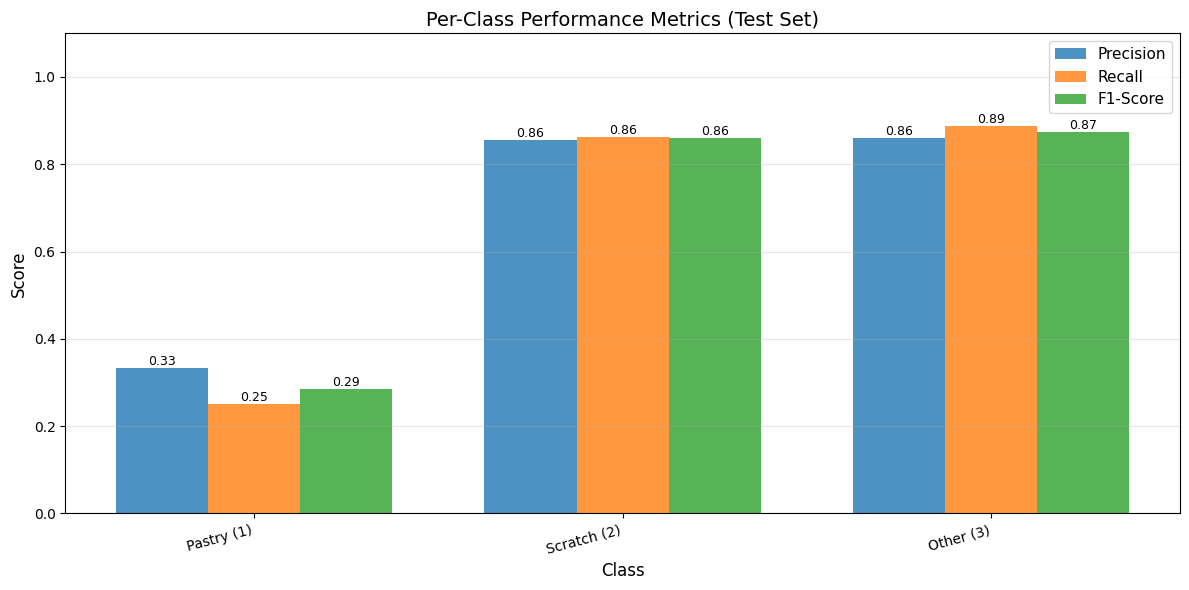

In [25]:
# Visualize per-class metrics
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(x - width, precision_per_class, width, label='Precision', alpha=0.8)
bars2 = ax.bar(x, recall_per_class, width, label='Recall', alpha=0.8)
bars3 = ax.bar(x + width, f1_per_class, width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Performance Metrics (Test Set)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

The `classification_report` provides a comprehensive summary of all metrics in one convenient table.

In [26]:
print("="*80)
print("CLASSIFICATION REPORT - TRAINING DATA")
print("="*80)
print(classification_report(
    y_train, 
    yhatTrain,
    target_names=class_names,
    digits=4
))

print("\n" + "="*80)
print("CLASSIFICATION REPORT - TEST DATA")
print("="*80)
print(classification_report(
    y_test, 
    yhatTest,
    target_names=class_names,
    digits=4
))

CLASSIFICATION REPORT - TRAINING DATA
              precision    recall  f1-score   support

  Pastry (1)     0.7093    0.5169    0.5980       118
 Scratch (2)     0.9231    0.9083    0.9156       436
   Other (3)     0.9011    0.9401    0.9202       901

    accuracy                         0.8962      1455
   macro avg     0.8445    0.7884    0.8113      1455
weighted avg     0.8921    0.8962    0.8927      1455


CLASSIFICATION REPORT - TEST DATA
              precision    recall  f1-score   support

  Pastry (1)     0.3333    0.2500    0.2857        40
 Scratch (2)     0.8562    0.8621    0.8591       145
   Other (3)     0.8613    0.8870    0.8740       301

    accuracy                         0.8272       486
   macro avg     0.6836    0.6664    0.6729       486
weighted avg     0.8163    0.8272    0.8211       486



### Understanding the Classification Report

The classification report shows:

1. **Per-class metrics:**
   - Precision: Of samples predicted as this class, what % were correct?
   - Recall: Of actual samples in this class, what % did we find?
   - F1-score: Harmonic mean of precision and recall
   - Support: Number of actual samples in this class

2. **Overall metrics:**
   - **Accuracy**: Overall % of correct predictions
   - **Macro avg**: Simple average across all classes (treats all classes equally)
   - **Weighted avg**: Average weighted by support (accounts for class imbalance)

**What to look for:**
- Large differences between training and test metrics → Overfitting
- Low precision for a class → Many false positives for that class
- Low recall for a class → Missing many samples of that class
- Low F1 for a class → Poor overall performance on that class
